In [1]:
import sys
import pandas as pd
import pickle
import importlib
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments
from pm4py.utils import get_properties

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../../')
sys.path.insert(0, '../../../../../')

In [2]:
!ls ../../simulator/procurement_event_log.csv

../../simulator/procurement_event_log.csv


In [3]:
# log as csv
event_log_path = '../../simulator/procurement_event_log.csv'
event_log_df = pd.read_csv(event_log_path)

case_id_key='case:concept:name'
activity_key='concept:name'
time_key='time:timestamp'

In [4]:
# load split CSVs

# for decision model training
train_csv_path = '../../../data/Procurement/raw_data/procurement_all_5_train.csv'
val_csv_path = '../../../data/Procurement/raw_data/procurement_all_5_val.csv'

df_train = pd.read_csv(train_csv_path)
df_val = pd.read_csv(val_csv_path)

# case IDs by split
case_ids_train = sorted(df_train[case_id_key].dropna().unique().tolist())
case_ids_val = sorted(df_val[case_id_key].dropna().unique().tolist())
case_ids_trainval = sorted(set(case_ids_train) | set(case_ids_val))

print('train cases:', len(case_ids_train))
print('val cases:', len(case_ids_val))
print('train+val cases:', len(case_ids_trainval))

def _prepare_split_log(base_df, keep_case_ids):
    out = base_df.copy()
    out = out[out[case_id_key].isin(set(keep_case_ids))]

    rename_map = {}
    if case_id_key in out.columns and case_id_key != 'case:concept:name':
        rename_map[case_id_key] = 'case:concept:name'
    if activity_key in out.columns and activity_key != 'concept:name':
        rename_map[activity_key] = 'concept:name'
    if time_key in out.columns and time_key != 'time:timestamp':
        rename_map[time_key] = 'time:timestamp'
    if rename_map:
        out = out.rename(columns=rename_map)

    if 'time:timestamp' in out.columns:
        out['time:timestamp'] = pd.to_datetime(out['time:timestamp'], errors='coerce')

    sort_cols = ['case:concept:name']
    if 'time:timestamp' in out.columns:
        sort_cols.append('time:timestamp')
    out = out.sort_values(sort_cols).reset_index(drop=True)
    return out

# for training
event_log_trainval = _prepare_split_log(event_log_df, case_ids_trainval)
print('train+val log rows:', len(event_log_trainval))

train cases: 6500
val cases: 1500
train+val cases: 8000
train+val log rows: 102776


In [5]:
# Minimal sanity check: timestamps must be datetime + sorted within each case
def _sanity_check_log(log_df, tag):
    case_col = 'case:concept:name'
    ts_col = 'time:timestamp'
    print(f'[{tag}] rows:', len(log_df))

    if ts_col in log_df.columns:
        is_dt = pd.api.types.is_datetime64_any_dtype(log_df[ts_col])
        print(f'[{tag}] time:timestamp is datetime:', is_dt)
        if not is_dt:
            print(f'[{tag}] WARNING: time:timestamp is not datetime; elapsed-time features may be wrong')

    if case_col in log_df.columns and ts_col in log_df.columns:
        neg = log_df.groupby(case_col)[ts_col].diff() < pd.Timedelta(0)
        n_bad = int(neg.fillna(False).sum())
        print(f'[{tag}] out-of-order timestamps (within case):', n_bad)
        if n_bad > 0:
            print(f'[{tag}] WARNING: log is not sorted within cases')

_sanity_check_log(event_log_trainval, 'train+val')

[train+val] rows: 102776
[train+val] time:timestamp is datetime: True
[train+val] out-of-order timestamps (within case): 0


In [6]:
# import petri net from the data loader: summarize only the behavior from the train and val set
petri_net_path = '../../../data/Procurement/Petri_net/procurement.pkl'
with open(petri_net_path, 'rb') as f:
    net, im, fm = pickle.load(f)

In [7]:

# Input: GenerateTransitionGuards Algorithm
# N = (P,T,F): A Petri net without data
petri_net=(net, im, fm)

# petri_net = (net, im, fm)
net, im, fm = petri_net

# EL (train+val): event log used for decision-model training
event_log_df_trainval = event_log_trainval

# A_trainval: optimal control-flow alignments of N and train+val log
params_trainval = get_properties(event_log_df_trainval)
params_trainval['ret_tuple_as_trans_desc'] = True

aligned_traces_trainval = alignments.apply(event_log_df_trainval, net, im, fm, parameters=params_trainval)
alignments_trainval = [a['alignment'] for a in aligned_traces_trainval]
print('train+val alignments:', len(alignments_trainval))

# Attributes used for decision mining
# dynamic: actually change value within a trace
#   - org:resource       : different resource performs each activity
#   - amount             : revised down on each rejection (_revise_case)
#   - budget_status      : flipped to "approved" after forced revision
#   - revision_count     : incremented on each rejection
#   - supplier_type      : None until Select Supplier
#   - goods_match        : None until Receive Goods
#   - invoice_deviation_pct : None until just before XOR-2
#   - case_elapsed_time  : computed, grows with each event
#   - event_elapsed_time : computed, per-event duration
dynamic_attributes = ['org:resource',
                      'amount',
                      'budget_status',
                      'revision_count',
                      'supplier_type',
                      'goods_match',
                      'invoice_deviation_pct',
                      'case_elapsed_time',
                      'event_elapsed_time']

# static: fixed for the entire trace, only vary across cases
#   - requester_seniority: chosen once at case start, never changed
#   - department         : from requester assignment, fixed per case
#   - category           : sampled once per case
#   - priority           : sampled once per case
static_attributes = ['requester_seniority',
                     'department',
                     'category',
                     'priority']


aligning log, completed variants ::   0%|          | 0/15 [00:00<?, ?it/s]

train+val alignments: 8000


In [8]:
import decision_mining.decision_discovery
importlib.reload(decision_mining.decision_discovery)
from decision_mining.decision_discovery import DecisionDiscovery

import decision_mining.function_estimator_catboost_advanced
importlib.reload(decision_mining.function_estimator_catboost_advanced)
from decision_mining.function_estimator_catboost_advanced import ModelConfig as AdvancedModelConfig

# Train decision models on train+val only
dd = DecisionDiscovery(petri_net=(net, im, fm),
                       sorted_case_ids=case_ids_trainval,
                       event_log_df=event_log_df_trainval,
                       alignments=alignments_trainval)

# Tuned CatBoost configuration for decision mining:
advanced_cfg = AdvancedModelConfig(cb_iterations=600,
                                   cb_learning_rate=0.05,
                                   cb_depth=6,
                                   cb_eval_fraction=0.15,
                                   cb_early_stopping_rounds=80,
                                   calibrate=False,
                                   surrogate_target='true_label',
                                   surrogate_top_k_features=20,
                                   surrogate_max_depth=5,
                                   surrogate_min_samples_leaf=40,
                                   surrogate_pruning_cv=3,
                                   surrogate_pruning_max_alphas=12,
                                   min_leaf_prob=0.15,
                                   min_leaf_lift=1.5,
                                   min_leaf_support=25)
print(advanced_cfg)

res = dd.mine_decision_models(dynamic_attributes=dynamic_attributes,
                              static_attributes=static_attributes,
                              mc_config=advanced_cfg)

# Interpretable probabilistic (set/range-based) guards
guards = dd.extract_guards(mining_result=res,
                           use_advanced_estimator=True)

print('Discovered guards:', guards)

# Save models + guard artifacts
output_dir = '../../../data/Procurement/Petri_net/data_aware_Petri_net'
result_paths = dd.save_results(guards=guards,
                               mining_result=res,
                               output_dir=output_dir)

print('Saved outputs:', result_paths)

discovery initialization completed!
ModelConfig(model_type='catboost', random_state=7, cb_iterations=600, cb_learning_rate=0.05, cb_depth=6, cb_l2_leaf_reg=3.0, cb_loss='Logloss', cb_eval_fraction=0.15, cb_early_stopping_rounds=80, cb_use_best_model=True, cb_thread_count=-1, cb_allow_writing_files=False, use_inverse_freq_weights=True, treat_int_as_categorical=True, low_card_max=30, high_card_top_k=50, min_category_freq=2, include_missing_token=True, surrogate_max_depth=5, surrogate_min_samples_leaf=40, surrogate_target='true_label', surrogate_top_k_features=20, surrogate_tune_ccp_alpha=True, surrogate_pruning_cv=3, surrogate_pruning_max_alphas=12, surrogate_pruning_metric='auto', calibrate=False, calibration_method='sigmoid', calibration_cv=3, guard_ci=0.95, include_missing_in_guards=False, min_leaf_prob=0.15, min_leaf_lift=1.5, min_leaf_support=25, always_keep_best=True, max_rules_per_label=12, rule_sort='score')
Discovered guards: {p_3: {'Approve Requisition': [{'rule': '(budget_stat

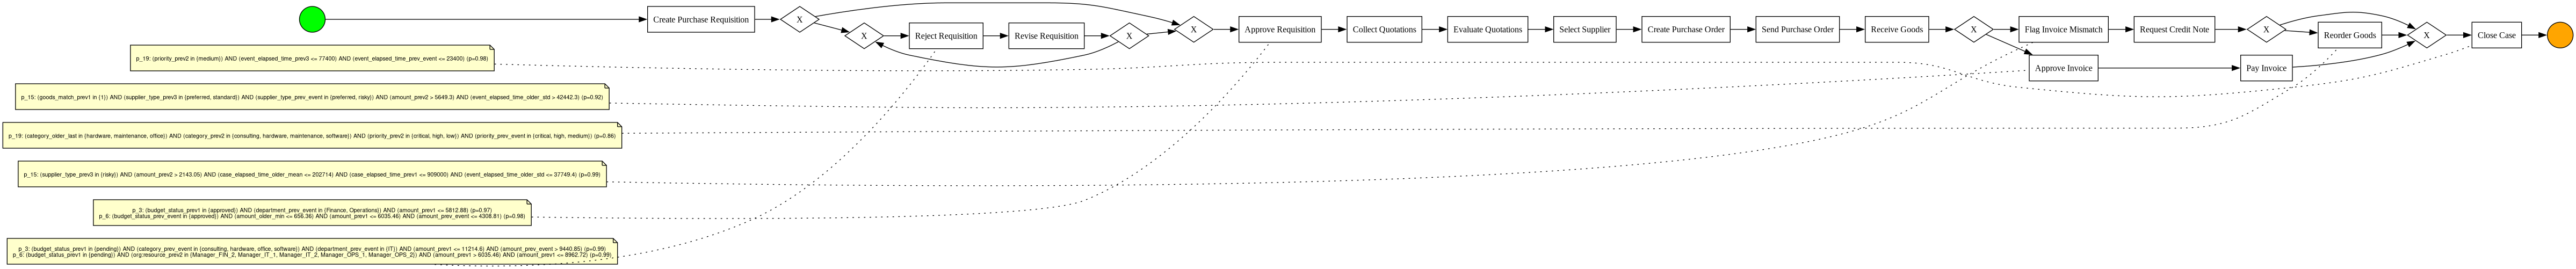

In [9]:
# BPMN visualization with decision rules annotated on exclusive gateways
dd.visualize_bpmn_with_rules(guards=guards)

## Test the decision mining

In [10]:
# Evaluate decision-label quality on held-out test set
from IPython.display import display
import pandas as pd

from data_processing.decision_labeling import (DecisionLabeler, compute_dp_diagnostics, extract_true_next_activities, BOTTOM)

# for evalaution only
test_csv_path = '../../../data/Procurement/raw_data/procurement_all_5_test.csv'
# test
df_test = pd.read_csv(test_csv_path)
case_ids_test = sorted(df_test[case_id_key].dropna().unique().tolist())

print('test cases:', len(case_ids_test))

# for testing
event_log_test = _prepare_split_log(event_log_df, case_ids_test)
print('test log rows:', len(event_log_test))

_sanity_check_log(event_log_test, 'test')

# EL_test / A_test: held-out data for evaluation
event_log_df_test = event_log_test
params_test = get_properties(event_log_df_test)
params_test['ret_tuple_as_trans_desc'] = True

aligned_traces_test = alignments.apply(event_log_df_test, net, im, fm, parameters=params_test)
alignments_test = [a['alignment'] for a in aligned_traces_test]
print('test alignments:', len(alignments_test))

labeler = DecisionLabeler(petri_net=(net, im, fm),
                          decision_model_dir=result_paths['model_dir'],
                          decision_places_bundle_path=result_paths['per_place_json_path'],
                          dynamic_attributes=dynamic_attributes,
                          static_attributes=static_attributes)

# Decision labels on test traces: (p_i, A_i, z_i, c_i)
test_labels_by_case = labeler.label_traces_offline(event_log_df=event_log_df_test,
                                                   sorted_case_ids=case_ids_test,
                                                   alignments=alignments_test)

# Align structure expected by diagnostics
decision_data_test = [test_labels_by_case.get(cid, []) for cid in case_ids_test]
true_next_test = extract_true_next_activities(event_log_df=event_log_df_test,
                                              sorted_case_ids=case_ids_test,
                                              alignments=alignments_test)

dp_diag = compute_dp_diagnostics(decision_data=decision_data_test,
                                 true_next_activities=true_next_test,
                                 coverage_threshold=0.0,
                                 n_calibration_bins=10)

diag_df = (pd.DataFrame.from_dict(dp_diag, orient='index').reset_index().rename(columns={'index': 'decision_place'}).sort_values('decision_place').reset_index(drop=True))

# Global weighted top-1 over all decision points on test
if not diag_df.empty:
    weighted_top1 = float((diag_df['top1_accuracy'] * diag_df['support']).sum() / diag_df['support'].sum())
    weighted_top3 = float((diag_df['top3_accuracy'] * diag_df['support']).sum() / diag_df['support'].sum())
    weighted_cov = float((diag_df['coverage'] * diag_df['support']).sum() / diag_df['support'].sum())
    print(f'Weighted test top1_accuracy: {weighted_top1:.4f}')
    print(f'Weighted test top3_accuracy: {weighted_top3:.4f}')
    print(f'Weighted test coverage: {weighted_cov:.4f}')

print('\nPer-decision-point diagnostics on test:')
display(diag_df)

# Compact c_i summary per decision point on test
ci_rows = []
for case_id in case_ids_test:
    for entry in test_labels_by_case.get(case_id, []):
        if not isinstance(entry, tuple) or len(entry) < 4:
            continue
        place_name, _, z_i, c_i = entry
        if place_name == BOTTOM or not z_i:
            continue
        ci_rows.append({'decision_place': place_name, 'c_i': float(c_i)})

ci_df = pd.DataFrame(ci_rows)
if not ci_df.empty:
    ci_summary = (ci_df.groupby('decision_place', as_index=False)['c_i'].agg(['count', 'mean', 'std', 'min', 'median', 'max']).reset_index().rename(columns={'count': 'support'}).sort_values('decision_place').reset_index(drop=True))
    print('\nTest c_i summary per decision point:')
    display(ci_summary)
else:
    print('\nNo decision-labeled test events found.')

test cases: 2000
test log rows: 25584
[test] rows: 25584
[test] time:timestamp is datetime: True
[test] out-of-order timestamps (within case): 0


aligning log, completed variants ::   0%|          | 0/15 [00:00<?, ?it/s]

test alignments: 2000
Weighted test top1_accuracy: 0.8509
Weighted test top3_accuracy: 1.0000
Weighted test coverage: 1.0000

Per-decision-point diagnostics on test:


,decision_place,support,entropy_mean,top1_accuracy,top3_accuracy,mean_true_prob,ece,coverage
0,p_15,2000.0,0.312477,0.896500,1.0,0.823553,0.032144,1.0
1,p_19,797.0,0.147946,0.974906,1.0,0.939301,0.016797,1.0
2,p_3,2000.0,0.321416,0.838000,1.0,0.803025,0.020463,1.0
3,p_6,1734.0,0.399779,0.756055,1.0,0.733922,0.061185,1.0



Test c_i summary per decision point:


,index,decision_place,support,mean,std,min,median,max
0,0,p_15,2000,0.866320,0.144668,0.500463,0.920446,0.995809
1,1,p_19,797,0.959704,0.048954,0.526222,0.974033,0.999267
2,2,p_3,2000,0.832096,0.192855,0.500008,0.958447,0.997555
3,3,p_6,1734,0.791697,0.182049,0.500350,0.891582,0.999622
